# Corner detection

Juan Diego Perez Navarro  
T00067699

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imutils

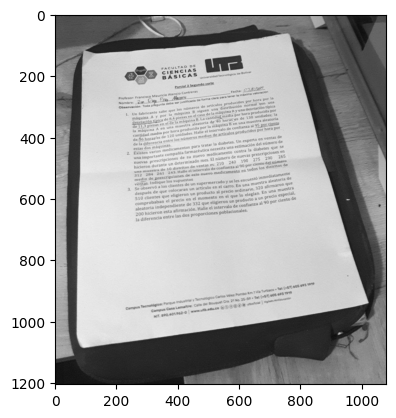

In [ ]:
img = cv2.imread('./images/image.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap = 'gray')
plt.show()

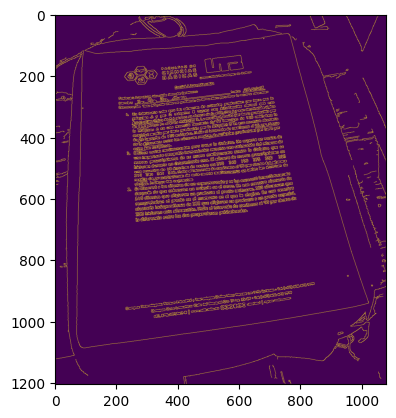

In [22]:
detail = cv2.detailEnhance(img,sigma_s = 20, sigma_r = 0.15)
gray = cv2.cvtColor(detail,cv2.COLOR_BGR2GRAY) # GRAYSCALE IMAGE
blur = cv2.GaussianBlur(gray,(5,5),0)

# edge detect
edge_image = cv2.Canny(blur,75,200)
plt.imshow(edge_image)

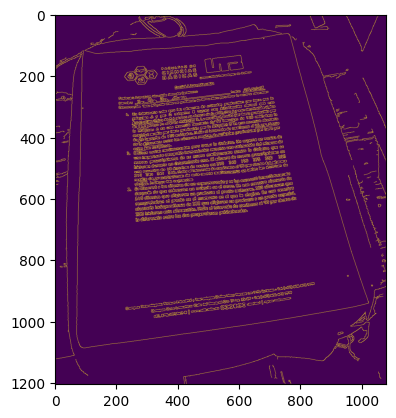

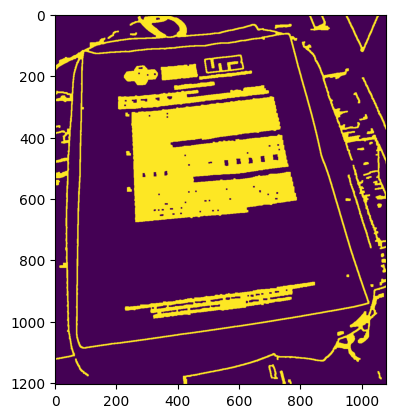

In [23]:
detail = cv2.detailEnhance(img,sigma_s = 20, sigma_r = 0.15)
gray = cv2.cvtColor(detail,cv2.COLOR_BGR2GRAY) # GRAYSCALE IMAGE
blur = cv2.GaussianBlur(gray,(5,5),0)

# edge detect
edge_image = cv2.Canny(blur,75,200)

# morphological transform
kernel = np.ones((5,5),np.uint8)
dilate = cv2.dilate(edge_image,kernel,iterations=1)
closing = cv2.morphologyEx(dilate,cv2.MORPH_CLOSE,kernel)

plt.imshow(edge_image)
plt.show()

plt.imshow(closing)
plt.show()

In [24]:
# find the contours
contours , hire = cv2.findContours(closing, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)
for contour in contours:
    perimeter = cv2.arcLength(contour,True)
    corners = cv2.approxPolyDP(contour,0.02*perimeter, True)

    if len(corners) == 4:
        four_points = np.squeeze(corners)
        break

cv2.drawContours(img,[four_points],-1,(0,255,0),3)
print()

In [25]:
four_points

array([[ 758,   67],
       [1016,  939],
       [  87, 1082],
       [  95,  123]], dtype=int32)

In [26]:
four_points[:,0]

array([ 758, 1016,   87,   95], dtype=int32)

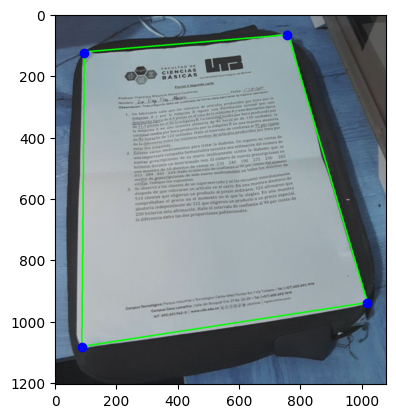

In [27]:
plt.imshow(img)
plt.plot(four_points[:,0],four_points[:,1], 'bo')
plt.show()

## Adjustar foto

In [112]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [113]:
width, height = img.shape[:2]

src_pts = np.array(sorted(four_points, key=np.sum), dtype="float32")
upper_left, upper_right, lower_left, lower_right = src_pts

In [114]:
display(src_pts, width, height)

array([[  95.,  123.],
       [ 758.,   67.],
       [  87., 1082.],
       [1016.,  939.]], dtype=float32)

1205

1080

### Sin que la hoja ocupe toda la foto

In [115]:
min_x = min(upper_left[0], upper_right[0], lower_left[0], lower_right[0])
max_x = max(upper_left[0], upper_right[0], lower_left[0], lower_right[0])
min_y = min(upper_left[1], upper_right[1], lower_left[1], lower_right[1])
max_y = max(upper_left[1], upper_right[1], lower_left[1], lower_right[1])

new_upper_left = [min_x, min_y]
new_upper_right = [max_x, min_y]
new_lower_left = [min_x, max_y]
new_lower_right = [max_x, max_y]

dst_pts = np.array([
    new_upper_left, new_upper_right,
    new_lower_left, new_lower_right
], dtype="float32")

In [116]:
dst_pts

array([[  87.,   67.],
       [1016.,   67.],
       [  87., 1082.],
       [1016., 1082.]], dtype=float32)

In [117]:
perspective = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped_img = cv2.warpPerspective(img, perspective, (height, width))

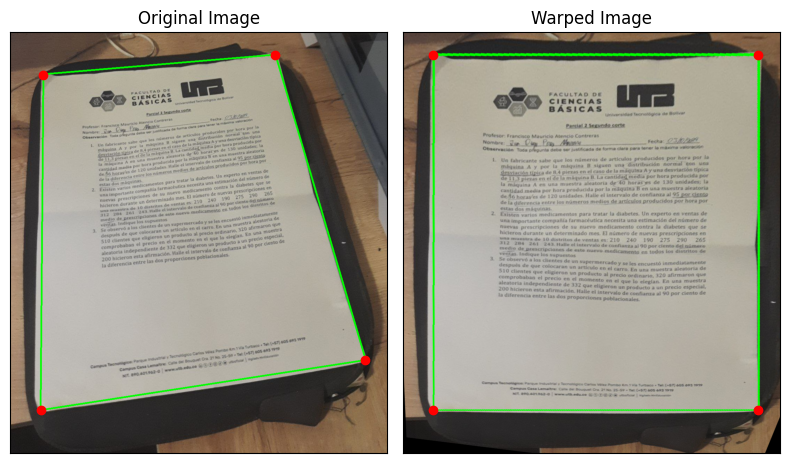

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(img)
axes[0].scatter(src_pts[:,0],src_pts[:,1], c='red')
axes[0].set_title('Original Image')

axes[1].set_title('Warped Image')
axes[1].scatter(dst_pts[:,0],dst_pts[:,1], c='red')
axes[1].imshow(warped_img)

for ax in axes:
    ax.set(xticks=[], yticks=[])

fig.tight_layout()
plt.show()

### La hoja ocupando toda la foto

In [119]:
min_x = 0
max_x = height - 1
min_y = 0
max_y = width - 1

new_upper_left = [min_x, min_y]
new_upper_right = [max_x, min_y]
new_lower_left = [min_x, max_y]
new_lower_right = [max_x, max_y]

dst_pts = np.array([
    new_upper_left, new_upper_right,
    new_lower_left, new_lower_right
], dtype="float32")

In [120]:
dst_pts

array([[   0.,    0.],
       [1079.,    0.],
       [   0., 1204.],
       [1079., 1204.]], dtype=float32)

In [121]:
perspective = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped_img = cv2.warpPerspective(img, perspective, (height, width))

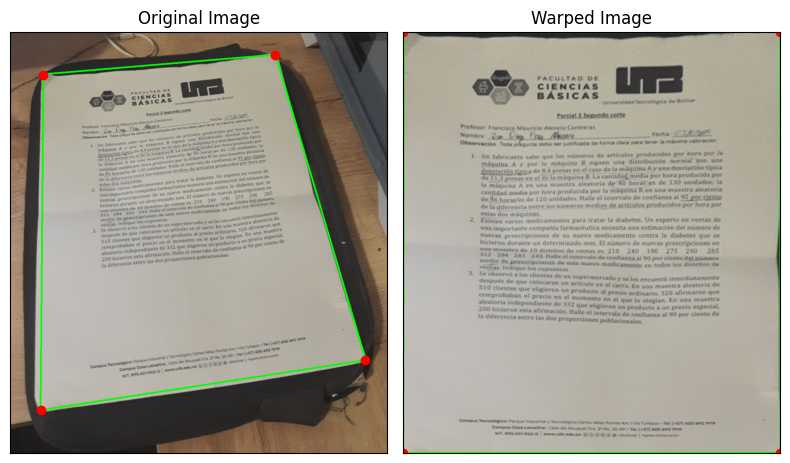

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(img)
axes[0].scatter(src_pts[:,0],src_pts[:,1], c='red')
axes[0].set_title('Original Image')

axes[1].set_title('Warped Image')
axes[1].scatter(dst_pts[:,0],dst_pts[:,1], c='red')
axes[1].imshow(warped_img)

for ax in axes:
    ax.set(xticks=[], yticks=[])

fig.tight_layout()
plt.show()